# MVP Análise de Dados e Boas Práticas

**Nome:** Bernardo Moraes Pereira

**Matrícula:** 4052025002069

**Dataset:** [Acidentes em Rodovias Federais no Brasil](https://www.kaggle.com/datasets/equeiroz/acidentes-rodovias-federais-brasil-jan07-a-jul19?resource=download&select=datatran2007.csv)



---



# Descrição do Problema

Somos uma empresa de consultoria especializada em Análise Exploratória de Dados (AED) e Ciência de Dados chamada "Data Insights". **Nosso time foi contratado pelos governadores do Sudeste do país** (RJ, SP, MG e ES) em uma iniciativa de entender **os fatores que potencializam riscos em acidentes** vividos pela população ao longo das rodoviais nesses estados.

Com intuito de direcionar o projeto, **foram passadas algumas hipóteses** que os governadores gostariam de comprovar através de dados para entender se as ações que eles estão pensando fazem sentido *(descritas no tópico de Hipóteses)*.

Para nos ajudar com o projeto, os governadores deixaram a nossa disposição o time de Engenharia de Dados responsável pela coleta e atualização desses dados. Eles nos disponibilizaram os dados com as seguintes informações:


>*Olá, time Data Insights!*
>
>*Para auxiliar vocês no trabalho estamos disponibilizando o dataset referente aos dados brutos de registros de ocorrências rodoviários.*
>
>*O dataset de Acidentes em Rodovias Federeais no Brasil consiste em registros de ocorrências (acidentes), onde **cada linha se refere a um registro**, incluindo dados de localidade, nome da BR, km, condições meteorológicas e da estrada, horário, causa e tipo do acidente, quantidades de feridos e mortos.*
>
>*Boa sorte com a análise!*
>
>*Abs,*
>
>*Time de Engenharia de Dados*

---

## Hipóteses

Como mencionado na Descrição do Problema, **foram traçadas as seguintes hipóteses**:


`Hipótese 1:` Acidentes noturnos (noite e madrugada) tem maior chance de resultar em mortes do que acidentes diurnos (manhã e tarde).

`Hipótese 2:` Acidentes em vias urbanas são mais comuns de resultarem em fatalidades (feridos graves ou mortos) do que em vias rurais.

`Hipótese 3:` Condições de pista ruins como chuva e neve estão diretamente ligadas a uma maior taxa de fatalidade em acidentes.

*Por fim, como **premissa do problema**, serão analisados apenas acidentes registrados no Sudeste, ou seja, com UF = {RJ, SP, MG, ES}.*

---

## Tipo de Problema

Este é um projeto de **classificação supervisionada multiclasse** com foco em acidentes rodoviários no Sudeste do Brasil. O objetivo é testar hipóteses sobre fatores de risco (fase do dia, tipo de via, uso do solo) e, adicionalmente, gerar insights estratégicos para políticas públicas, como priorização de fiscalização e investimentos em infraestrutura.



---



## Seleção dos Dados

O dataset utilizado no trabalho foi obtido através da plataforma Kaggle: [Acidentes em Rodovias Federais no Brasil](https://www.kaggle.com/datasets/equeiroz/acidentes-rodovias-federais-brasil-jan07-a-jul19?resource=download&select=datatran2007.csv).

Não foram necessárias etapas de seleção de dados externos ou a importação de outros datasets, dentro do conjunto de dados selecionado já foram encontradas as informações necessárias para desenvolver o trabalho.

Como premissa, foram aplicadas as restrições de analisar apenas os estados do sudeste (filtrando a coluna "UF").

Além disso, como podemos ver ao acessar o dataset, os dados se referem a acidentes ao longo do ano de 2007. Para fins de storytelling do MVP, esses dados foram alterados para o ano de 2025 (sem interferir em nada nas características ou informações que a base apresenta, essa mudança foi feita apenas para compor o storytelling de "analisarmos o ano de 2025 para aprensentar aos governadores nesse momento do ano de 2026 que estamos").



---



## Atributos do Dataset

O dataset possui 23 atributos que foram classificados da seguinte forma:

**1. Atributo Identificador:** não utilizado para análises estatísticas, apenas para identificar registros únicos ao longo do conjunto;

**2. Atributo Categórico:** qualitativos representando características ou categorias, não aplicáveis a cálculos aritméticos diretos;

**3. Atributo Numérico:** quantitativo representando medidas do conjunto.

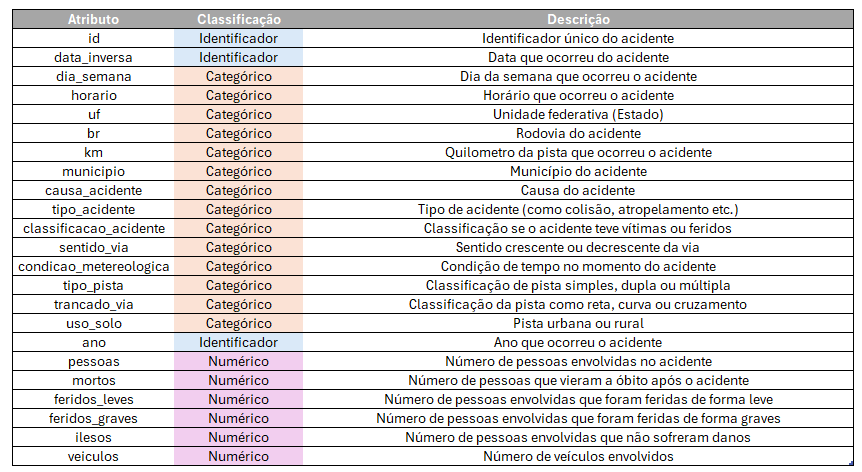

---

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset de Acidentes em Rodovias Federais no Brasil.

O dataset foi obtido a partir de um repositório no GitHub e será carregado utilizando sua URL pública.

---

In [37]:
# Importando bibliotecas utilizadas no trabalho

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [38]:
# Carregando o dataset e armazenando um um dataframe nomeado "df_base"

url = "https://raw.githubusercontent.com/bemoraesp27/mvp_ciencia_e_analise_de_dados/main/Base_acidentes.xlsx"
df_base = pd.read_excel(url, sheet_name="base_acidentes_2025")


In [39]:
# Visualizando as primeiras linhas do dataframe

df_base.head()


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,tipo_pista,tracado_via,uso_solo,ano,pessoas,mortos,feridos_leves,feridos_graves,ilesos,veiculos
0,10,11/06/2025,Segunda,15:30:00,MG,381,623.2,OLIVEIRA,Falta de atenção,Colisão frontal,...,Dupla,Reta,Rural,2025,9,0,4,0,5,6
1,10,11/06/2025,Segunda,15:30:00,MG,381,623.2,OLIVEIRA,Falta de atenção,Colisão frontal,...,Dupla,Reta,Rural,2025,9,0,4,0,5,6
2,1032898,13/08/2025,Segunda,14:25:00,MG,40,585.5,ITABIRITO,Outras,Saída de Pista,...,Simples,Reta,Rural,2025,3,0,0,1,2,1
3,1051130,12/02/2025,Segunda,02:10:00,MA,135,11,SAO LUIS,Animais na Pista,Atropelamento de animal,...,Simples,Reta,Urbano,2025,5,2,2,1,0,1
4,1066824,20/11/2025,Terça,05:30:00,CE,222,30.8,CAUCAIA,Defeito mecânico em veículo,Capotamento,...,Dupla,Reta,Rural,2025,1,0,1,0,0,1


*⚠ Um ponto importante já identificado na etapa de trazer as primeiras linhas do nosso dataset é a **existência de ids duplicados do mesmo registro. Isso será importante para ser tratado na fase de Pré Processamento**.*

Como uma etapa adicional no momento de importação, faremos um passo para direcionar o trabalho:

Como o time de Engenharia de dados nos disponibilizou o dataset com **registros de todo o Brasil e nossa análise será direcionada apenas ao Sudeste, vamos realizar um filtro no nosso dataset para manter apenas essas UFs**.


In [40]:
# Realizando o filtro para deixar apenas UFs do Sudeste

ufs_desejadas = ['RJ', 'SP', 'MG', 'ES']

df_base = df_base[df_base["uf"].isin(ufs_desejadas)]


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset selecionado vamos entender as distribuição das variáveis analisadas, suas dispersões e características. Assim como compreender, a partir dessa exploração, os pontos de atenção para serem tratados na etapa de Pré-Processamento de Dados.

## Total e Tipo das Instâncias

Observamos que o dataset analisado tem **49.625 instâncias** quando analisamos o recorte do Sudeste, sendo dividido em:
- 11.670 registros no RJ;
- 11.109 registros em SP;
- 20.601 registros em MG;
- 6.241 registros no ES;

Temos também dois tipos de características nesse dataset:

1. **Dimensões do acidente**, basicamente sendo as colunas de Dtype = object, onde trazemos características de contexto do acidente (data do registro, município, horário, características da via, causa e classificação do acidente etc.

2. **Valores númericos "fato" desse acidente**, como número de veículos, pessoas envolvidas, feridos e mortos.



In [41]:
print(f"Total de instâncias: {len(df_base)}")
print("\nTipos de dados por coluna:")
print(df_base.info())

Total de instâncias: 49625

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
Index: 49625 entries, 0 to 127670
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      49625 non-null  int64 
 1   data_inversa            49625 non-null  object
 2   dia_semana              49625 non-null  object
 3   horario                 49625 non-null  object
 4   uf                      49625 non-null  object
 5   br                      49625 non-null  object
 6   km                      49625 non-null  object
 7   municipio               49625 non-null  object
 8   causa_acidente          49625 non-null  object
 9   tipo_acidente           49625 non-null  object
 10  classificacao_acidente  49625 non-null  object
 11  sentido_via             49625 non-null  object
 12  condicao_metereologica  49625 non-null  object
 13  tipo_pista              49625 non-null  object
 14  tra

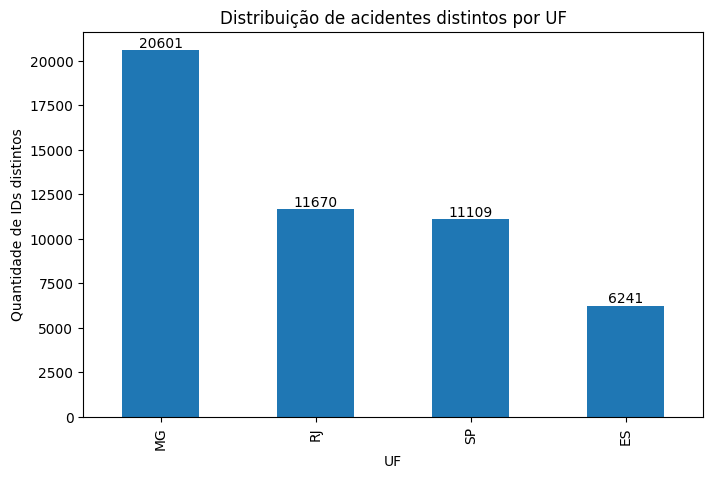

In [42]:
# Distribuição de instâncias por UF

contagem_acidentes = (
    df_base.groupby("uf")["id"]
    .nunique()
    .sort_values(ascending=False)
)

ax = contagem_acidentes.plot(kind="bar", figsize=(8,5))
ax.bar_label(ax.containers[0])
plt.xlabel("UF")
plt.ylabel("Quantidade de IDs distintos")
plt.title("Distribuição de acidentes distintos por UF")
plt.show()




## Estatística Descritiva

Como objetivo desta etapa, vamos analisar de forma exploratórias algumas características do nosso dataset a partir de algumas diretrizes (distribuição, média, desvio padrão, mínimo, máximo, quartis etc).


### Quadro Estatístico

Neste momento vamos analisar nossas principais variáveis númericas de modo a resumi-lás de forma estatística com a ideia de **identificar dispersões e pontos de atenção** como outliers para nossas análises futuras.

In [43]:
# Variáveis que vamos analisar
variaveis = ['pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'veiculos']

stats = df_base[variaveis].describe().T.copy()
stats['median'] = df_base[variaveis].median()

# Adicionar moda (primeira moda em caso de empate)
stats['mode'] = df_base[variaveis].mode().iloc[0]

# Adicionar contagem de valores ausentes
stats['missing'] = df_base[variaveis].isnull().sum()

# Ordenando matriz
stats = stats[['count', 'min', 'max', 'mean', 'median', 'mode', 'std', '25%', '75%', 'missing']]
stats.columns = ['N', 'Mín', 'Máx', 'Média', 'Mediana', 'Moda', 'Desvio-Padrão', 'Q1 (25%)', 'Q3 (75%)', 'Ausentes']

# Visualizar com arredondamento
display(stats.round(2))


,N,Mín,Máx,Média,Mediana,Moda,Desvio-Padrão,Q1 (25%),Q3 (75%),Ausentes
pessoas,49625.0,1.0,59.0,2.02,2.0,2,1.46,1.0,2.0,0
mortos,49625.0,0.0,9.0,0.04,0.0,0,0.26,0.0,0.0,0
feridos_leves,49625.0,0.0,43.0,0.41,0.0,0,1.08,0.0,1.0,0
feridos_graves,49625.0,0.0,27.0,0.16,0.0,0,0.56,0.0,0.0,0
ilesos,49625.0,0.0,42.0,1.36,1.0,1,0.98,1.0,2.0,0
veiculos,49625.0,1.0,10.0,1.67,2.0,2,0.72,1.0,2.0,0


💡**Principais Insights a partir do resumo de dispersões:**

`Pessoas`
- Média e Mediana próximas significa que de fato a maioria dos acidentes envolvem 2 pessoas;
- Máximo de 59 pessoas extremamente distante da Média e Mediana indica um possível outlier.

`Mortos`
- Mediana como 0 e Média como 0,04 indicam que a maioria dos acidentes não tem mortos;
- Máximo de 9 significa que tem poucos acidentes muito graves;
- Moda como 0 e Desvio Padrão de 0,26 confirmam que acidentes fatais são raros.

`Feridos Leve`
- Mediana como 0 e Média como 0,41 também indicam que a maioria dos acidentes não tem feridos leves;
- Máximo de 43 indica um outlier bem alto a ser tratado;
- Q3 = 1 indica que 75% dos acidentes tem **até** 1 ferido leve.

`Feridos Graves`
- Mediana como 0 e Média como 0,16 indicam acidentes graves são ainda mais raros;
- Novamente um máximo alto indicando outlier;
- Q1 e Q3 = 0 indicando que só uma minoria de acidentes tem feridos graves.

### Distribuição de Atributos

Nesta fase vamos **analisar de forma gráfica as dispersões das variáveis** vistas de forma resumida no tópico anterior de quadro estatístico.

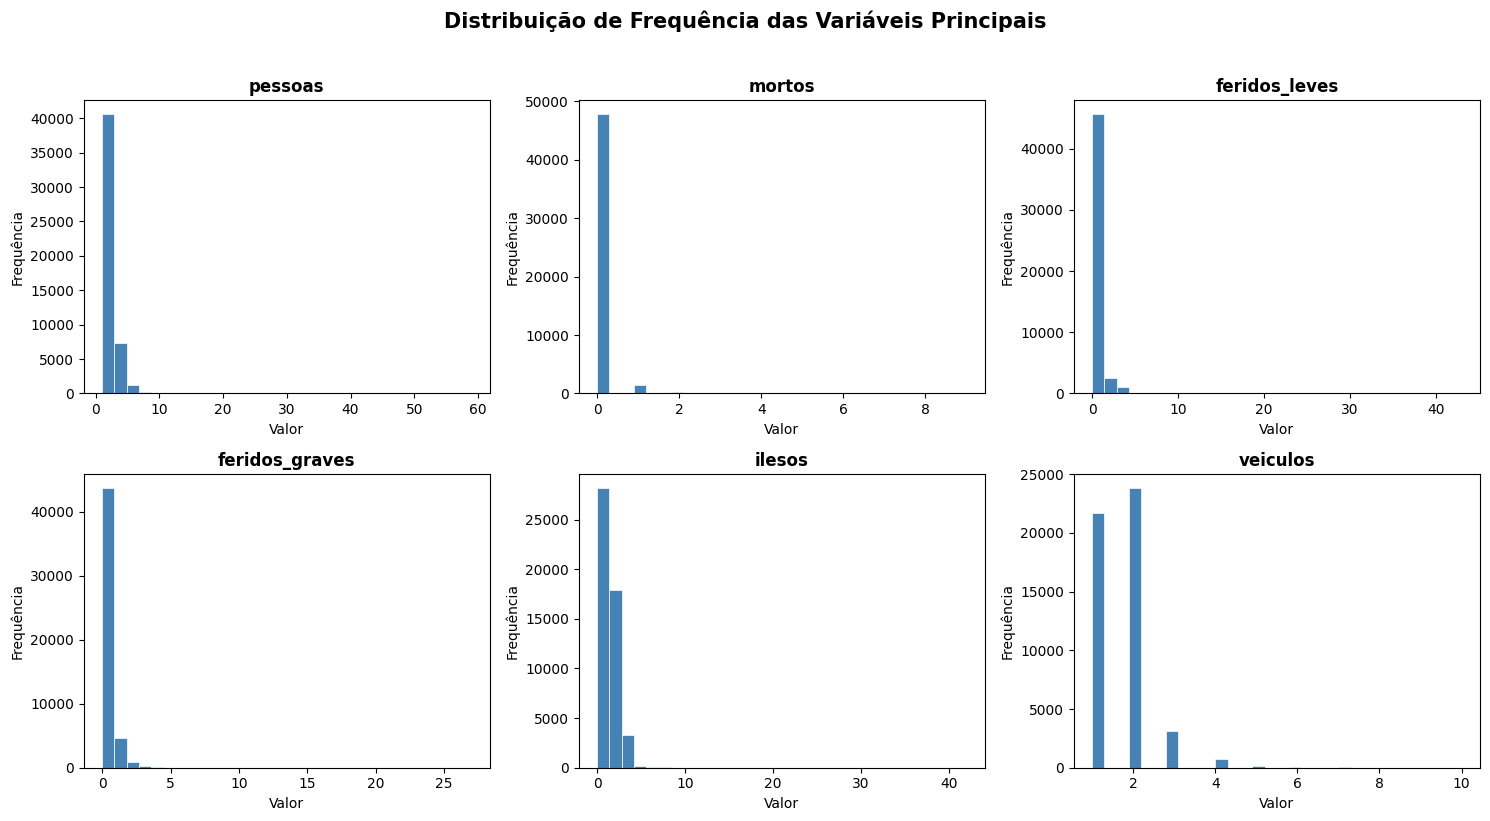

In [44]:
# Lista das variáveis principais
variaveis = ['pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'veiculos']

# Definir número de linhas e colunas da grade
n_rows, n_cols = 2, 3  # 2 linhas x 3 colunas = 6 variáveis
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8))
axes = axes.flatten()  # transforma grade em array 1D

# Loop para criar cada histograma
for i, col in enumerate(variaveis):
    axes[i].hist(df_base[col], bins=30, edgecolor='white', linewidth=0.5, color='steelblue')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')

# Ajustar layout e título geral
plt.suptitle('Distribuição de Frequência das Variáveis Principais', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()





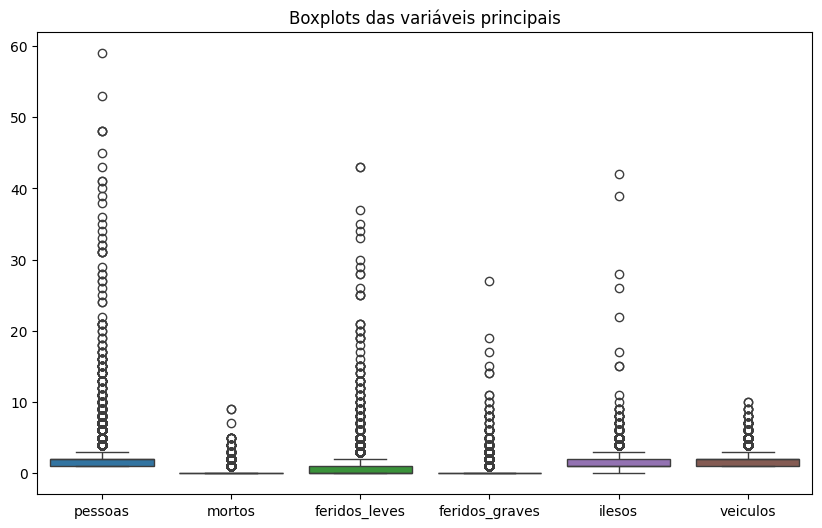

In [45]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_base[variaveis])
plt.title('Boxplots das variáveis principais')
plt.show()


💡 **Principais insights do boxplot:**

Temos uma **distribuição bastante assimétrica**, tendo uma maior concentração de valores e medianas baixas, mas em ambas as variáveis outliers bem altos.

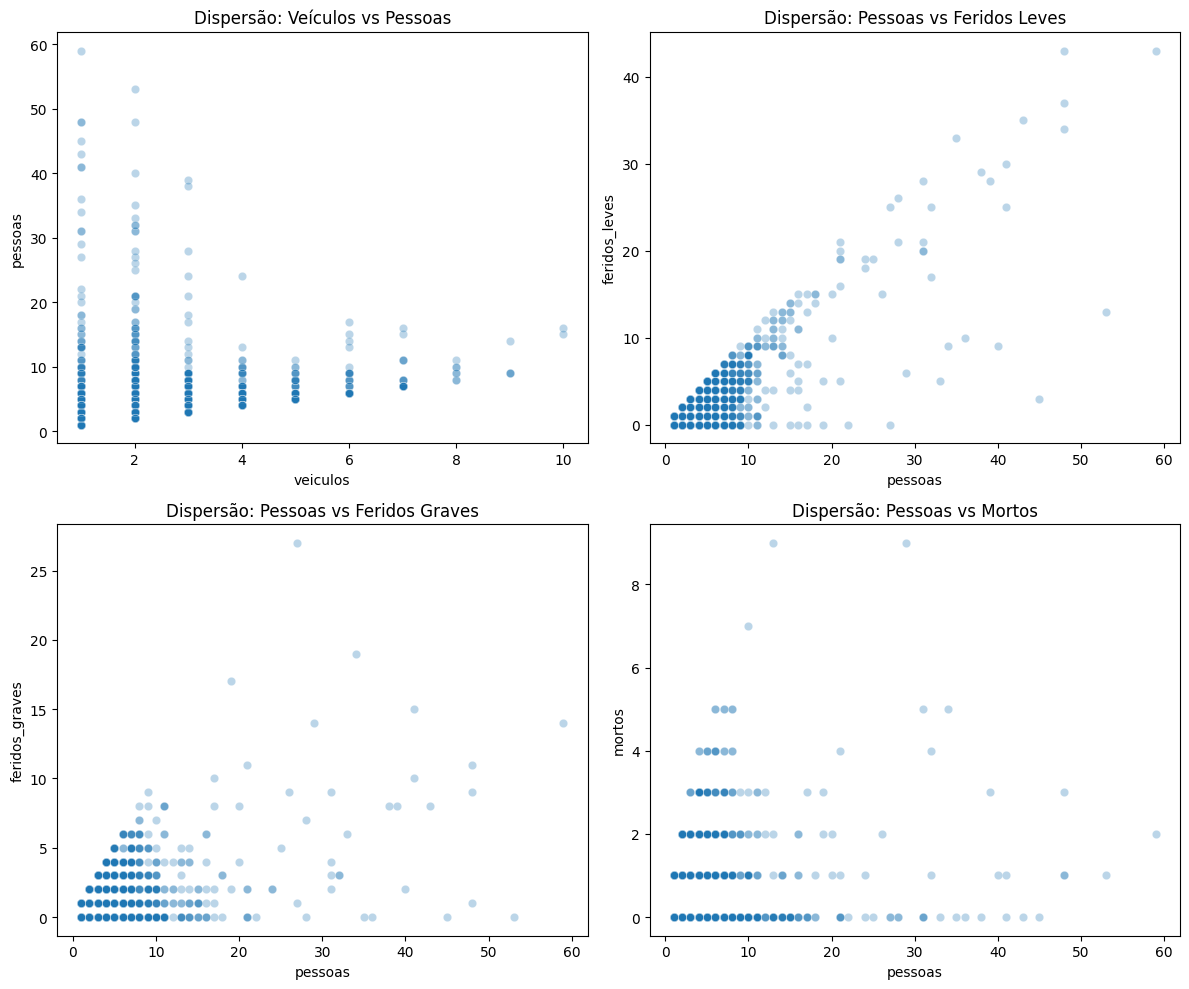

In [46]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gráfico 1: Veículos vs Pessoas
sns.scatterplot(x='veiculos', y='pessoas', data=df_base, alpha=0.3, ax=axes[0,0])
axes[0,0].set_title('Dispersão: Veículos vs Pessoas')

# Gráfico 2: Pessoas vs Feridos Leves
sns.scatterplot(x='pessoas', y='feridos_leves', data=df_base, alpha=0.3, ax=axes[0,1])
axes[0,1].set_title('Dispersão: Pessoas vs Feridos Leves')

# Gráfico 3: Pessoas vs Feridos Graves
sns.scatterplot(x='pessoas', y='feridos_graves', data=df_base, alpha=0.3, ax=axes[1,0])
axes[1,0].set_title('Dispersão: Pessoas vs Feridos Graves')

# Gráfico 4: Pessoas vs Mortos
sns.scatterplot(x='pessoas', y='mortos', data=df_base, alpha=0.3, ax=axes[1,1])
axes[1,1].set_title('Dispersão: Pessoas vs Mortos')

plt.tight_layout()
plt.show()


💡**Principais insights do gráfico de dispersão:**

`Veículos vs Pessoas`
- Conforme aumenta o número de veículos, o número de pessoas envolvidas não cresce proporcionalmente;
- Os pontos mais altos (muitos envolvidos) aparecem mesmo em acidentes com poucos veículos, ou seja, indicam ônibus, vans ou veículos coletivos.

`Pessoas vs Feridos Leves`
- Temos uma correlação positiva, indicando que quanto mais pessoas envolvidas, maior o número de feridos leves, o que faz sentido, quanto mais pessoas expostas ao risco, maior a chance de termos feridos.

`Pessoas vs Feridos Graves`
-  Acidentes com muitos envolvidos não necessariamente geram muitos feridos graves, mas quando acontecem, são casos excepcionais.

`Feridos Graves`
- Não tendo uma correlação linear também.

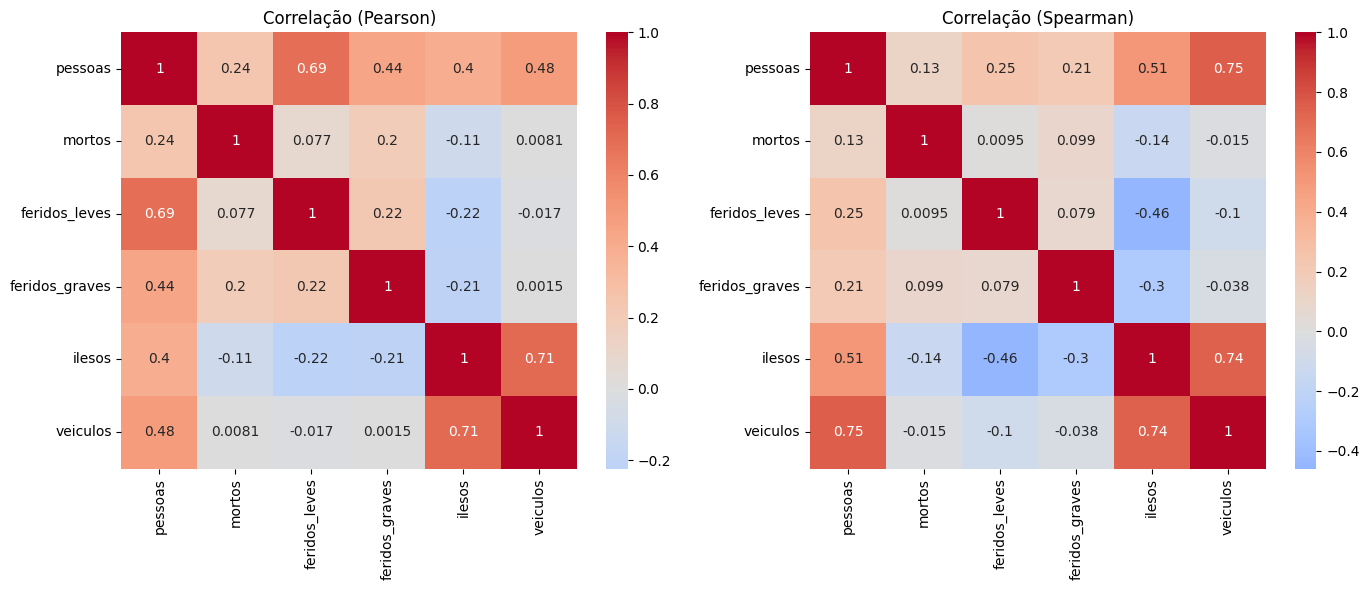

In [47]:
variaveis = ['pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'veiculos']

# Calcular correlações
corr_pearson = df_base[variaveis].corr(method='pearson')
corr_spearman = df_base[variaveis].corr(method='spearman')

# Criar figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap Pearson
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Correlação (Pearson)')

# Heatmap Spearman
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlação (Spearman)')

plt.tight_layout()
plt.show()


💡**Principais insights do gráfico de correlação:**

`Correlação de Pearson`

*(Utilizada por medir a relação linear entre variáveis numa escala de -1 a +1, sendo boa para variáveis conctínuas como pessoas, veículos e feridos leves).*

- Pessoas vs Feridos Leves (0.69), mostrando uma correlação positiva forte, onde mais pessoas envolvidas = mais feridos leves.
- Pessoas vs Feridos Graves (0.44), indicando correlação moderada;
- Pessoas vs Mortos (0.24), indicando correlação fraca, confirmando que mortes não aumentam proporcionalmente com número de pessoas;
- Veículos vs Ilesos (0.71), tendo uma correlação forte, ou seja, quanto mais veículos mais pessoas ilesas, o que faz sentido em colisões leves;
- Mortos motra uma correlação baixa com todas as variáveis, mostrando que fatalidades são pouco previsíveis pelos atributos numéricos.

`Correlação de Spearman`

*(Utilizada para medir relações não lineares, sendo útil para distribuição muito assimétricas, como mortos e feridos graves, onde temos uam grande concentração de valores 0).*

-  Pessoas vs Mortos (0.24) mostrando correlação fraca, confirmando que mortes não aumentam proporcionalmente com número de pessoas.


### Tratamento de Valores Nulos

Nesta etapa vamos avaliar a disposição de valores nulos ao longo dos nossos atributos do dataset para identificar uma possível necessidade de tratamento nesses casos.

In [48]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset:")
df_base.isnull().sum()

Valores nulos no dataset:


,0
id,0
data_inversa,0
dia_semana,0
horario,0
uf,0
br,0
km,0
municipio,0
causa_acidente,0
tipo_acidente,0


💡Como **não foram identificados valores nulos** nos atributos, não temos a necessidade de tratar o nosso dataset visando esse ponto.

# Pré Processamento de Dados

Nesta etapa iremos limpar e tratar o nosso dataset a partir do que levantamos na etapa de análise exploratória, além de modelar nossos dados de forma a prepara-los para responder nossas hipóteses e futuramente para otimizar o desempenho do algoritmo.

## Tratamentos Inciais

Como analisamos, temos um ponto principal para ser tratado no nosso dataset de forma inicial:
- Remoção de duplicatas (ao avaliarmos o dataset, vimos que existem IDs duplicados, signifcando mais de uma linha para o mesmo registro).

In [49]:
# Verificar duplicatas pelo id
duplicados = df_base[df_base.duplicated(subset='id', keep=False)]
display(duplicados)

# Contar quantos duplicados existem
display(df_base.duplicated(subset='id').sum())


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,tipo_pista,tracado_via,uso_solo,ano,pessoas,mortos,feridos_leves,feridos_graves,ilesos,veiculos
0,10,11/06/2025,Segunda,15:30:00,MG,381,623.2,OLIVEIRA,Falta de atenção,Colisão frontal,...,Dupla,Reta,Rural,2025,9,0,4,0,5,6
1,10,11/06/2025,Segunda,15:30:00,MG,381,623.2,OLIVEIRA,Falta de atenção,Colisão frontal,...,Dupla,Reta,Rural,2025,9,0,4,0,5,6
40555,224331,05/05/2025,Sábado,20:45:00,SP,116,107,TAUBATE,Outras,Colisão lateral,...,Dupla,Reta,Urbano,2025,2,0,0,0,1,2
40556,224331,05/05/2025,Sábado,20:45:00,SP,116,107,TAUBATE,Outras,Colisão lateral,...,Dupla,Reta,Urbano,2025,2,0,0,0,1,2
72478,263322,07/08/2025,Terça,17:10:00,ES,101,284,CARIACICA,Falta de atenção,Colisão Transversal,...,Simples,Curva,Rural,2025,3,0,0,2,1,2
72479,263322,07/08/2025,Terça,17:10:00,ES,101,284,CARIACICA,Falta de atenção,Colisão Transversal,...,Dupla,Curva,Rural,2025,3,0,0,2,1,2
93839,287779,10/10/2025,Quarta,08:30:00,ES,262,7.1,CARIACICA,Falta de atenção,Colisão lateral,...,Dupla,Cruzamento,Urbano,2025,2,0,0,0,2,2
93840,287779,10/10/2025,Quarta,08:30:00,ES,262,7.1,CARIACICA,Falta de atenção,Colisão lateral,...,Múltipla,Curva,Urbano,2025,2,0,0,0,2,2


np.int64(4)

In [50]:
#Removendo os ids duplicados mantendo o primeiro registro
df_base = df_base.drop_duplicates(subset='id', keep='first')

## Discretização

Como uma das primeiras etapas de Pré Processamento, vamos aplicas a Discretização para criação da faixas em nosso dataset.


1. Tratamento de discretização sobre a hipótese 1: "Acidentes noturnos (noite e madrugada) tem maior chance de resultar em mortes do que acidentes diurnos (manhã e tarde)."

Como já analisamos que não existem valores nulos no nosso dataset, podemos realizar a criação da faixa do dia, para isso, seguiremos a seguinte lógica:
- Madrugada = 00h-06h;
- Manhã = 06h-12h;
- Tarde = 12h-18h;
- Noite = 18h-00h.

In [51]:
# Converter coluna 'horario' para datetime
df_base['horario'] = pd.to_datetime(df_base['horario'], format='%H:%M:%S')

# Extrair apenas a hora (0 a 23)
df_base['hora'] = df_base['horario'].dt.hour

def categorizar_fase_dia(hora):
    if 0 <= hora < 6:
        return 'Madrugada'
    elif 6 <= hora < 12:
        return 'Manhã'
    elif 12 <= hora < 18:
        return 'Tarde'
    else:
        return 'Noite'

df_base['fase_dia'] = df_base['hora'].apply(categorizar_fase_dia)

#Verificando as primeiras linhas e a proporção da nova categoria
display(df_base[['horario','hora','fase_dia']].head())
display(df_base['fase_dia'].value_counts())


,horario,hora,fase_dia
0,1900-01-01 15:30:00,15,Tarde
2,1900-01-01 14:25:00,14,Tarde
7,1900-01-01 22:30:00,22,Noite
8,1900-01-01 20:30:00,20,Noite
9,1900-01-01 21:10:00,21,Noite


,count
fase_dia,
Tarde,15932
Noite,13606
Manhã,13380
Madrugada,6703


1. Tratamento de discretização sobre a hipótese 2: "Acidentes em vias urbanas são mais comuns de resultarem em fatalidades (feridos graves ou mortos) do que em vias rurais."

Como um primeiro passo, vamos analisar os valores que existem em nossa coluna de condição metereológica:

In [52]:
df_base['condicao_metereologica'].unique()


array(['Ceu Claro', 'Chuva', 'Nublado', 'Sol', 'Nevoeiro/neblina',
       'Granizo', 'Ignorada', '(null)', 'Vento', 'Neve'], dtype=object)

⚠ **Aqui temos um ponto importante, mesmo verificando se existiam valores nulos no nosso dataset (e o resultado dando que não existem), vemos que aqui existem linhas com o valor '(null)'.**

Isso ocorre pois esse valor não está vazio, mas sim sendo uma string com esse valor.

Antes de pensarmos em próximos passos, vamos verificar quantas linhas existem com cada categoria:

In [53]:
df_base['condicao_metereologica'].value_counts()

,count
condicao_metereologica,
Ceu Claro,23891
Chuva,9224
Nublado,8525
Sol,6414
Ignorada,1001
Nevoeiro/neblina,434
Vento,108
Granizo,11
(null),9


Para prepararmos a nossa base para responder a hipótese 3 "Condições de pista ruins como chuva e neve estão diretamente ligadas a uma maior taxa de fatalidade em acidentes.", **não faz sentido considerarmos valores null ou ignorados em nossa análise**, pois não agregam en nada.

Porém, **para não excluirmos 1.010 registros da nossa base** (linhas com valor null ou ignorados) **e não impactar nas outras hipótestes**, vamos **criar um dataframe derivado da nossa base original** expurgando esses valores.

Dessa forma, mantemos a nossa base original sem impacto e criamos uma nova base que nos possibilite analisar a condição metereológica sem esses casos que não agregam valor para a análise.

In [54]:
# Criar um novo dataframe filtrado
df_base_h3 = df_base.copy()

# Substituir "(null)" por NaN, caso ainda exista
df_base_h3['condicao_metereologica'] = df_base_h3['condicao_metereologica'].replace("(null)", np.nan)

# Excluir nulos e "Ignorada"
df_base_h3 = df_base_h3.dropna(subset=['condicao_metereologica'])
df_base_h3 = df_base_h3[df_base_h3['condicao_metereologica'] != 'Ignorada']


Agora, em nosso novo dataframe destinado para trabalharmos na hipótese 3, vamos criar a faixa com as condições metereologicas, seguinte a lógica:
- Ceu Claro = Condição Boa;
- Chuva = Condição Ruim;
- Nublado = Condição Boa;
- Sol = Condição Boa;
- Nevoeiro/neblina = Condição Ruim;
- Vento = Condição Boa;
- Granizo = Condição Ruim;
- Neve = Condição Ruim;

In [55]:
# Mapear categorias para seca vs molhada
mapa = {
    'Ceu Claro': 'Condição Boa',
    'Sol': 'Condição Boa',
    'Nublado': 'Condição Boa',
    'Vento': 'Condição Boa',
    'Chuva': 'Condição Ruim',
    'Granizo': 'Condição Ruim',
    'Neve': 'Condição Ruim',
    'Nevoeiro/Neblina': 'Condição Ruim'
}

df_base_h3['condicao_pista'] = df_base_h3['condicao_metereologica'].map(mapa)

#Verificando as primeiras linhas e a proporção da nova categoria
display(df_base_h3[['condicao_pista','condicao_metereologica']].head())
display(df_base_h3['condicao_pista'].value_counts())


,condicao_pista,condicao_metereologica
0,Condição Boa,Ceu Claro
2,Condição Boa,Ceu Claro
7,Condição Boa,Ceu Claro
8,Condição Ruim,Chuva
9,Condição Boa,Nublado


,count
condicao_pista,
Condição Boa,38938
Condição Ruim,9239


## Feature Engineering

Nesta etapa, vamos utilizar o método de feature engineering, baseado em **criar/transformar variáveis (features) para melhorar a análise** e desempenho do modelo.

Para a Hipótese 1 criaremos a variável binária de "mortos_binário", indicando se houve mortos ou não no acidente.

Para a Hipótese 2 criaremos a variável binária "fatalidade", indicando se houve mortos ou feridos graves no acidente.

Para a Hipótese 3, seguiremos a mesma lógica de criar a variável binária "fatalidade", porém criaremos no nosso datafrema específico para a hipótese 3.

In [56]:
# Criar variável binária de fatalidade
df_base['mortos_binario'] = (df_base['mortos'] > 0).astype(int)

# Conferir distribuição
display(df_base['mortos_binario'].value_counts())


,count
mortos_binario,
0,47879
1,1742


In [57]:
# Criar variável binária de fatalidade (mortos + feridos graves)
df_base['fatalidade'] = ((df_base['mortos'] > 0) | (df_base['feridos_graves'] > 0)).astype(int)

# Conferir distribuição
display(df_base['fatalidade'].value_counts())


,count
fatalidade,
0,42469
1,7152


In [58]:
# Criar variável binária de fatalidade (mortos + feridos graves) para H3
df_base_h3['fatalidade'] = ((df_base_h3['mortos'] > 0) | (df_base_h3['feridos_graves'] > 0)).astype(int)

# Conferir distribuição
display(df_base_h3['fatalidade'].value_counts())


,count
fatalidade,
0,41649
1,6962


## Padronização

Para responder nossos testes estatíticos com intuito de validar as hipóteses traçadas, não há necessidade de realizar padronização do nosso dataset. Mas com intuito de testar a técnica, vamos criar um novo dataframe apelidade de "df_base_treino", onde iremos aplicar a técnica simulando a padronização dos nosso dados para futuramente aplicarmos em um modelo de predição.

Nessa técnica, utilizaremos duas frentes principais:

**1. Log-transform:** indicada para variáveis muito enviesadas de cauda longa (como pessoas, veiculos e feridos leves), onde aplicamos o logaritmo aos valores, comprimindo os números grandes e aproximando a distribuição normal. Dessa forma, reduzimos o impactos dos outliers extremos que identificamos durante a etapa de AED.

**2. Sqrt-transform:** indicada para variáveis de valores moderados e poucos outliers (como feridos graves e mortos), onde aplicamos a raiz quadrada nos valores, suavizando valores grandes mas de forma menos agressiva. Com isso, podemos manter a escala mais próxima da original sem reduzir os pesos dos extremos.

In [59]:
# Colunas de cada transformação
colunas_log = ['pessoas', 'veiculos', 'feridos_leves']
colunas_sqrt = ['feridos_graves', 'mortos']

# Pipeline para colunas com log-transform + padronização
log_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p, validate=True)),
    ('scale', StandardScaler())
])

# Pipeline para colunas com sqrt-transform + padronização
sqrt_pipeline = Pipeline([
    ('sqrt', FunctionTransformer(np.sqrt, validate=True)),
    ('scale', StandardScaler())
])

# ColumnTransformer aplicando cada pipeline no seu grupo
preprocess = ColumnTransformer(
    transformers=[
        ('log_pipeline', log_pipeline, colunas_log),
        ('sqrt_pipeline', sqrt_pipeline, colunas_sqrt)
    ],
    remainder='passthrough'  # mantém as demais variáveis sem alteração
)

# Aplicar transformações ao dataset original
df_base_treino_array = preprocess.fit_transform(df_base)

# Recuperar nomes das colunas finais
colunas_final = colunas_log + colunas_sqrt + [
    c for c in df_base.columns if c not in colunas_log + colunas_sqrt
]

# Criar novo DataFrame de treino
df_base_treino = pd.DataFrame(df_base_treino_array, columns=colunas_final)

# Visualizar primeiras linhas para conferir
display(df_base_treino.head())





,pessoas,veiculos,feridos_leves,feridos_graves,mortos,id,data_inversa,dia_semana,horario,uf,...,condicao_metereologica,tipo_pista,tracado_via,uso_solo,ano,ilesos,hora,fase_dia,mortos_binario,fatalidade
0,3.979437,3.982138,3.315188,-0.354011,-0.18681,10,11/06/2025,Segunda,1900-01-01 15:30:00,MG,...,Ceu Claro,Dupla,Reta,Rural,2025,5,15,Tarde,0,0
1,1.08125,-1.032966,-0.544754,2.29242,-0.18681,1032898,13/08/2025,Segunda,1900-01-01 14:25:00,MG,...,Ceu Claro,Simples,Reta,Rural,2025,2,14,Tarde,0,1
2,0.171324,-1.032966,-0.544754,2.29242,-0.18681,1137914,12/08/2025,Domingo,1900-01-01 22:30:00,ES,...,Ceu Claro,Múltipla,Reta,Urbano,2025,1,22,Noite,0,1
3,1.08125,-1.032966,2.090066,-0.354011,-0.18681,1179288,04/02/2025,Domingo,1900-01-01 20:30:00,MG,...,Chuva,Simples,Curva,Rural,2025,1,20,Noite,0,0
4,1.08125,-1.032966,2.780019,-0.354011,-0.18681,1254853,22/11/2025,Quinta,1900-01-01 21:10:00,MG,...,Nublado,Simples,Reta,Urbano,2025,0,21,Noite,0,0


**Agora vamos visualizar as distribuições antes e depois da padronização:**

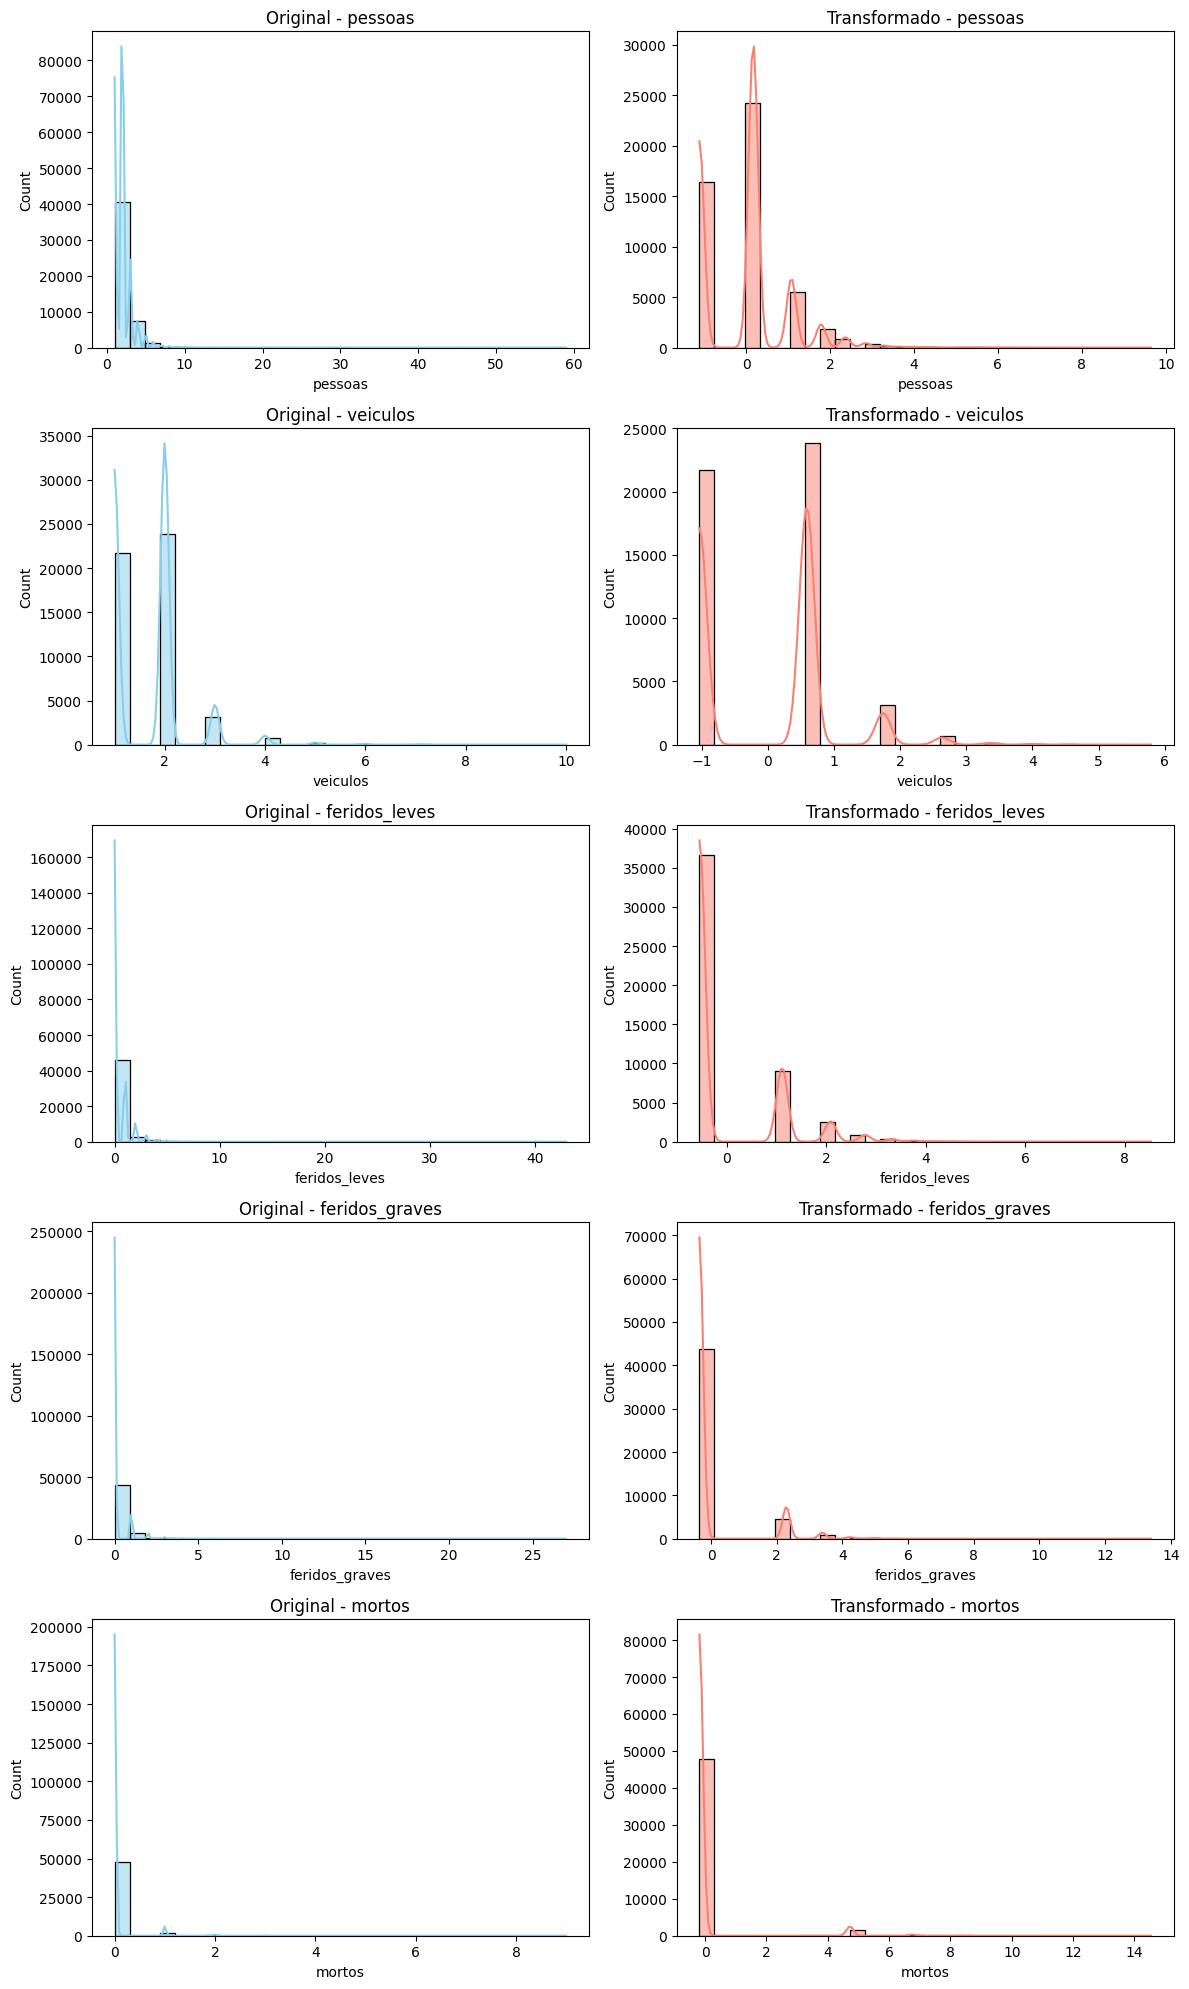

In [60]:
# Lista das variáveis transformadas
variaveis = colunas_log + colunas_sqrt

# Criar subplots: 2 colunas (original vs transformado) para cada variável
fig, axes = plt.subplots(len(variaveis), 2, figsize=(12, 4*len(variaveis)))

for i, var in enumerate(variaveis):
    # Original
    sns.histplot(df_base[var], bins=30, ax=axes[i,0], kde=True, color='skyblue')
    axes[i,0].set_title(f"Original - {var}")

    # Transformado
    sns.histplot(df_base_treino[var], bins=30, ax=axes[i,1], kde=True, color='salmon')
    axes[i,1].set_title(f"Transformado - {var}")

plt.tight_layout()
plt.show()


# Respondendo nossas Hipóteses

Nesta etapa, a partir dos tratamentos e modelagem da etapa de Pré Processamento, estamos aptos a responder as hipóteses levantadas no início do trabalho.

## Hipótese 1

`Hipótese 1:` Acidentes noturnos (noite e madrugada) tem maior chance de resultar em mortes do que acidentes diurnos (manhã e tarde).

**Passo 1:** Como primeiro passo vamos realizar o teste Qui-quadrado para entender se existe associação entre fase do dia e mortes.

Nessa análise conseguiremos ver dois fatores principais:

1. O qui-quadrado, medindo o quanto os valores observados diferem dos esperados:

- Se a diferença for pequena, não há associação.
- Se a diferença for grande, há associação.

2. O p-valor indicando se essa diferença é estatisticamente significativa.

In [61]:
# Criar tabela de contingência
contingencia = pd.crosstab(df_base['fase_dia'], df_base['mortos_binario'])

# Aplicar teste qui-quadrado
chi2, p, dof, expected = chi2_contingency(contingencia)

display("Qui-quadrado:", chi2)
display("p-valor:", p)
display("Graus de liberdade:", dof)
display("Tabela esperada:", expected)


'Qui-quadrado:'

np.float64(266.070508415978)

'p-valor:'

np.float64(2.1856709482698116e-57)

'Graus de liberdade:'

3

'Tabela esperada:'

array([[ 6467.68378308,   235.31621692],
       [12910.28032486,   469.71967514],
       [13128.3463453 ,   477.6536547 ],
       [15372.68954676,   559.31045324]])

💡Com os resultados do teste podemos observar:

- Qui-quadrado = 266.07, indicando um valor alto, ou seja, há uma diferença entre o valor observado e esperado.

- p-valor = 2.19, indicando um valor extremamente baixo, ou seja, a associação entre fase do dia e mortes é estatisticamente significativa, dessa forma, em termos práticos, a distribuição de mortes não é aleatória em relação ao período do dia.

**Passo 2:** Agora que o teste Qui-quadrado já nos mostrou que existe associação, vamos analisar as proporções observadas para entender qual faixa do dia possui um maior risco, assim, conseguiremos ver quais tem a maior diferença com a tabela esperada.

mortos_binario,0,1
fase_dia,,
Madrugada,0.943906,0.056094
Manhã,0.979671,0.020329
Noite,0.952006,0.047994
Tarde,0.972320,0.027680


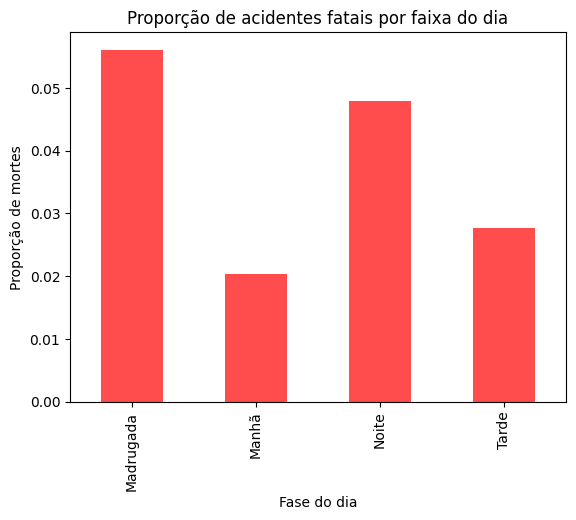

In [62]:
# Tabela de contingência normalizada por linha (fase_dia)
proporcoes = pd.crosstab(df_base['fase_dia'], df_base['mortos_binario'], normalize='index')

display(proporcoes)

proporcoes[1].plot(kind='bar', color='red', alpha=0.7)
plt.title("Proporção de acidentes fatais por faixa do dia")
plt.ylabel("Proporção de mortes")
plt.xlabel("Fase do dia")
plt.show()



💡Com os resultados comprovamos nossa hipótese: as maiores barras indicam uma maior diferença entre o observado x esperado na madrugada e noite. Dessa forma, mostrando que essas faixas do dia estão mais associadas a mortes.

**Passo 3:** Como complemento da nossa análise, vamos utilizar a técnica de regressão logística para transformar os resultados em uma medida prática, como se fossem "odds", dessa forma, conseguiremos entender o quão maior é o risco de morte nas faixas da noite e madrugada.

In [63]:
#Para calcular as odds, primeiro utilizaremos a faixa da manhã como referência
# Definir manhã como referência
modelo_manha = smf.logit("mortos_binario ~ C(fase_dia, Treatment(reference='Manhã'))", data=df_base).fit()

print(modelo_manha.summary())

# Odds Ratios
odds_ratios_manha = np.exp(modelo_manha.params)
display("Odds Ratios (referência = Manhã):\n", odds_ratios_manha)



Optimization terminated successfully.
         Current function value: 0.149413
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         mortos_binario   No. Observations:                49621
Model:                          Logit   Df Residuals:                    49617
Method:                           MLE   Df Model:                            3
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                 0.01745
Time:                        20:55:21   Log-Likelihood:                -7414.0
converged:                       True   LL-Null:                       -7545.7
Covariance Type:            nonrobust   LLR p-value:                 8.515e-57
                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept           

'Odds Ratios (referência = Manhã):\n'

,0
Intercept,0.020751
"C(fase_dia, Treatment(reference='Manhã'))[T.Madrugada]",2.863898
"C(fase_dia, Treatment(reference='Manhã'))[T.Noite]",2.429463
"C(fase_dia, Treatment(reference='Manhã'))[T.Tarde]",1.371913


💡Como resultado da regressão logística, utilizando a faixa da manhã como referência, vemos que a madrugada tem 2.86 vezes mais chance de ocorrer em mortes e a noite tem 2.42 vezes, comprovando nossa hipótese.

In [64]:
# Agora utilizando a tarde como referência
modelo_tarde = smf.logit("mortos_binario ~ C(fase_dia, Treatment(reference='Tarde'))", data=df_base).fit()

print(modelo_tarde.summary())

# Odds Ratios
odds_ratios_tarde = np.exp(modelo_tarde.params)
display("Odds Ratios (referência = Tarde):\n", odds_ratios_tarde)


Optimization terminated successfully.
         Current function value: 0.149413
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         mortos_binario   No. Observations:                49621
Model:                          Logit   Df Residuals:                    49617
Method:                           MLE   Df Model:                            3
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                 0.01745
Time:                        20:55:28   Log-Likelihood:                -7414.0
converged:                       True   LL-Null:                       -7545.7
Covariance Type:            nonrobust   LLR p-value:                 8.515e-57
                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept           

'Odds Ratios (referência = Tarde):\n'

,0
Intercept,0.028468
"C(fase_dia, Treatment(reference='Tarde'))[T.Madrugada]",2.087521
"C(fase_dia, Treatment(reference='Tarde'))[T.Manhã]",0.728909
"C(fase_dia, Treatment(reference='Tarde'))[T.Noite]",1.770858


💡Assim como utilizando a faixa da tarde como referência, observamos que a madrugada tem 2.08 vezes e a noite 1.77, também indicando uma maior probabilidade de ocorrer em mortes do que a faixa da tarde.

## Hipótese 2

`Hipótese 2:` Acidentes em vias urbanas são mais comuns de resultarem em fatalidades (feridos graves ou mortos) do que em vias rurais.

**Passo 1:** Seguiremos a mesma lógica da primeira hipótese, realizando um teste Qui-quadrado para determinar associação entre a o uso do solo e as fatalidades. Caso o valor observado e esperado tenham uma diferença significativa isso irá nos indicar que o uso do solo tem influência nas fatalidades de acidentes.

In [65]:
# Tabela de contingência
contingencia = pd.crosstab(df_base['uso_solo'], df_base['fatalidade'])

# Teste qui-quadrado
chi2, p, dof, expected = chi2_contingency(contingencia)

display("Qui-quadrado:", chi2)
display("p-valor:", p)
display("Graus de liberdade:", dof)
display("Tabela esperada:\n", expected)


'Qui-quadrado:'

np.float64(105.0584137029688)

'p-valor:'

np.float64(1.1858784300026829e-24)

'Graus de liberdade:'

1

'Tabela esperada:\n'

array([[23285.58640495,  3921.41359505],
       [19183.41359505,  3230.58640495]])

💡Com os resultados do teste podemos observar:

Observamos que existe uma associação estatisticamente significativa entre o uso do solo e ocorrências de fatalidadesm ou seja, a proporção de fatalidades entre solo urbano e rural não são iguais, mostrando que essa diferença não é fruto do acaso.

**Passo 2:** Agora que o teste Qui-quadrado já nos mostrou que existe associação, como temos apenas duas categorias, vamos utilizar o teste de proporções (z-test) para entender a diferença entre a proporção de fatalidades dentro de cada categoria.

In [66]:
# Contagens
contingencia = pd.crosstab(df_base['uso_solo'], df_base['fatalidade'])
sucessos = contingencia.loc[:,1].values   # número de fatalidades
n = contingencia.sum(axis=1).values       # total de acidentes

# Teste de proporções
ztest, pval = sm.stats.proportions_ztest(sucessos, n)

print("Z-test:", ztest)
print("p-valor:", pval)


Z-test: 10.262642247344147
p-valor: 1.038262210683337e-24


In [67]:
# Proporção de fatalidade em cada tipo de via
proporcoes = pd.crosstab(df_base['uso_solo'], df_base['fatalidade'], normalize='index')
display(proporcoes)


fatalidade,0,1
uso_solo,,
Rural,0.841181,0.158819
Urbano,0.873695,0.126305


💡Com os resultados do teste podemos observar:

Na vida Rural temos proporção de aproximadamente 15.9% de fatalidades, enquanto em vias Urbanas temos 12.6%, reforçando que em vias rurais temos uma maior proporção de acidentes envolvendo feridos graves ou mortes.

**Passo 3:** Por fim, iremos calcular as odds de ratio das duas categorias para entender o quão maior são as chances de uma acidente em vias rurais acarretar em fatalidades do que em vias urbanas.

In [68]:
# Modelo logístico com Urbano como referência
modelo = smf.logit("fatalidade ~ C(uso_solo, Treatment(reference='Urbano'))", data=df_base).fit()

display(modelo.summary())

# Odds Ratios
odds_ratios = np.exp(modelo.params)
display("Odds Ratios:\n", odds_ratios)



Optimization terminated successfully.
         Current function value: 0.411325
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             fatalidade   No. Observations:                49621
Model:                          Logit   Df Residuals:                    49619
Method:                           MLE   Df Model:                            1
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                0.002594
Time:                        20:55:45   Log-Likelihood:                -20410.
converged:                       True   LL-Null:                       -20463.
Covariance Type:            nonrobust   LLR p-value:                 6.796e-25
=======================================================================================================================
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                                              -1.9340      0.020    -96.186      0.000      -1.973      -1.895
C(uso_solo, Treatment(reference='Urbano'))[T.Rural]     0.2670      0.026     10.243      0.000       0.216       0.318
=======================================================================================================================
"""

'Odds Ratios:\n'

,0
Intercept,0.144564
"C(uso_solo, Treatment(reference='Urbano'))[T.Rural]",1.306032


💡Comprovando que nossa hipótese inicial estava equivocada, vemos que acidentes rurais tem 1.3 vezes mais chances de ocorrerem fatalidades do que em vias urbanas.

## Hipótese 3

`Hipótese 3:` Condições de pista ruins como chuva e neve estão diretamente ligadas a uma maior taxa de fatalidade em acidentes.

**Passo 1:** Seguiremos a mesma lógica das primeiras hipóteses, realizando um teste Qui-quadrado para determinar associação entre a o condição da pista e as fatalidades. Caso o valor observado e esperado tenham uma diferença significativa isso irá nos indicar que a condição da pista tem influência nas fatalidades de acidentes.

In [69]:
# Tabela de contingência
contingencia = pd.crosstab(df_base_h3['condicao_pista'], df_base_h3['fatalidade'])

# Teste qui-quadrado
chi2, p, dof, expected = chi2_contingency(contingencia)

display("Qui-quadrado:", chi2)
display("p-valor:", p)
display("Graus de liberdade:", dof)
display("Tabela esperada:\n", expected)

'Qui-quadrado:'

np.float64(102.32779559516264)

'p-valor:'

np.float64(4.705433374860516e-24)

'Graus de liberdade:'

1

'Tabela esperada:\n'

array([[33363.65153496,  5574.34846504],
       [ 7916.34846504,  1322.65153496]])

💡Com os resultados do teste podemos observar que existe associação significa também entre as condições da pista e fatalidades, não tendo proporções iguais e tendo incluência.

**Passo 2:** Seguiremos agora para analisar as proporções.

In [70]:
# Contagens
contingencia = pd.crosstab(df_base_h3['condicao_pista'], df_base_h3['fatalidade'])
sucessos = contingencia.loc[:,1].values   # número de fatalidades
n = contingencia.sum(axis=1).values       # total de acidentes

# Teste de proporções
ztest, pval = sm.stats.proportions_ztest(sucessos, n)

display("Z-test:", ztest)
display("p-valor:", pval)


'Z-test:'

np.float64(10.132240994597227)

'p-valor:'

np.float64(3.97434691068033e-24)

In [71]:
# Proporção de fatalidade em cada condição de pista
proporcoes = pd.crosstab(df_base_h3['condicao_pista'], df_base_h3['fatalidade'], normalize='index')
display(proporcoes)

fatalidade,0,1
condicao_pista,,
Condição Boa,0.848965,0.151035
Condição Ruim,0.890031,0.109969


💡Com os resultados do teste podemos observar:

Em condições boas temos uma proporção de fatalidade de 15.1%, enquanto em condições ruins de 10.9%, o que chama atenção por ir na direção contrário a nossa hipóteste.

Ou seja, o teste de proporção mostra que há uma diferença real, mas que em condições boas temos uma proporção maior. Isso pode fazer sentido se pensarmos que em condições ruins os motoristas podem dirigir mais devagar e de forma cautelosa.

**Passo 3:** Por fim, iremos calcular as odds de ratio das duas categorias para entender o quão maior são as chances de uma acidente em condições ruins acarretar em fatalidades do que em condições boas.

In [72]:
# Modelo logístico com "Condição Boa" como referência
modelo = smf.logit("fatalidade ~ C(condicao_pista, Treatment(reference='Condição Boa'))", data=df_base_h3).fit()

display(modelo.summary())

# Odds Ratios
odds_ratios = np.exp(modelo.params)
display("Odds Ratios:\n", odds_ratios)


Optimization terminated successfully.
         Current function value: 0.409532
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             fatalidade   No. Observations:                48177
Model:                          Logit   Df Residuals:                    48175
Method:                           MLE   Df Model:                            1
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                0.002741
Time:                        20:55:56   Log-Likelihood:                -19730.
converged:                       True   LL-Null:                       -19784.
Covariance Type:            nonrobust   LLR p-value:                 2.136e-25
===========================================================================================================================================
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                  -1.7265      0.014   -121.994      0.000      -1.754      -1.699
C(condicao_pista, Treatment(reference='Condição Boa'))[T.Condição Ruim]    -0.3646      0.036    -10.087      0.000      -0.435      -0.294
===========================================================================================================================================
"""

'Odds Ratios:\n'

,0
Intercept,0.177905
"C(condicao_pista, Treatment(reference='Condição Boa'))[T.Condição Ruim]",0.694505


💡Para nossa surpresa, a odds de fatalidade em condições ruins é 0.694 vezes MENOR do que em condições boas. Em outras palavras,pista ruim reduz a chance de fatalidade em aproximadamente 30,6% em relação à pista boa, contradizendo nossa hipóteste inicial.

# Conclusão

Analisando as hipóteses traçadas no trabalho inicialmente vemos que:


`Hipótese 1:` Acidentes noturnos (noite e madrugada) tem maior chance de resultar em mortes do que acidentes diurnos (manhã e tarde).

**A Hipótese 1 se mostrou verdadeira** visto que se utilizarmos a faixa da manhã, temos:
- 2.86 vezes mais chance de morte na madrugada e 2.42 a noite;

Assim como utilizando a tarde como referência temos:
- 2.08 vezes mais chance de morte na madrugada e 1.77 vezes a noite.

Dessa forma, **nossa hipótese 1 está VALIDADA**.

`Hipótese 2:` Acidentes em vias urbanas são mais comuns de resultarem em fatalidades (feridos graves ou mortos) do que em vias rurais.

**Já na hipótese 2, vemos que ela se mostrou INCORRETA**, pois acidentes rurais tem 1.3 vezes mais chance de ocorrerem em fatalidades do que acidentes em vias urbanas.

`Hipótese 3:` Condições de pista ruins como chuva e neve estão diretamente ligadas a uma maior taxa de fatalidade em acidentes.

Por fim, em nossa **hipótese 3, vemos que ela também se mostrou INCORRETA**, pois vimos que condições ruins geram 30.6% menos de chance de ocorrerem fatalidades do que em condições boas.

Além disso, **a partir da AED vimos a importancia de padronizar nosso dataset em caso da criação de um modelo de predição**, visto a quantidade de outliers e a influência/impacto que eles podem gerar em nosso dataset.